# SVM Periyar - Combined

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, precision_score, recall_score)
from sklearn.svm import SVC
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids
import warnings

warnings.filterwarnings("ignore")

# ==== Load Dataset ====
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["wkt_geom"], inplace=True, errors="ignore")
df = df.fillna(0)

# ==== Features and Target ====
X = df.drop(columns=["Target_Var"])
y = df["Target_Var"]
classes = sorted(y.unique())

# ==== Train-Test Split ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== Apply ClusterCentroids (Undersampling Majority Class) ====
cc = ClusterCentroids(random_state=42, sampling_strategy='auto')  # Automatically balance classes
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# ==== Apply Borderline SMOTE (Oversampling Minority Class) ====
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # Focus on minority class
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# ==== Scale ====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ==== Feature Selection ====
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train_res)
sfm = SelectFromModel(rf_selector, prefit=True, threshold="median")
X_train_selected = sfm.transform(X_train_scaled)
X_test_selected = sfm.transform(X_test_scaled)

# ==== Evaluation Function ====
def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)
    print(f"\n================ {name} =================")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score :", classification_report(y_true, y_pred, output_dict=True)["weighted avg"]["f1-score"])
    print("AUC ROC  :", roc_auc_score(y_true, y_proba, multi_class='ovr'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# ==== SVM with GridSearch ====
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf']
}

svm = GridSearchCV(
    SVC(probability=True, decision_function_shape='ovr'),
    svm_params, cv=3, scoring='accuracy', n_jobs=-1
)
svm.fit(X_train_selected, y_train_res)

# ==== Evaluate ====
evaluate_model("SVM (Multi-Class with SMOTE and ClusterCentroids)", svm.best_estimator_, X_test_selected, y_test)



================ SVM (Multi-Class with SMOTE and ClusterCentroids) =================
Accuracy : 0.6709844559585493
Precision: 0.7259912820263758
Recall   : 0.6709844559585493
F1-score : 0.6633357075569416
AUC ROC  : 0.849568817831638
Confusion Matrix:
 [[471 165 329]
 [ 24 367  50]
 [ 65   2 457]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.49      0.62       965
           1       0.69      0.83      0.75       441
           2       0.55      0.87      0.67       524

    accuracy                           0.67      1930
   macro avg       0.69      0.73      0.68      1930
weighted avg       0.73      0.67      0.66      1930



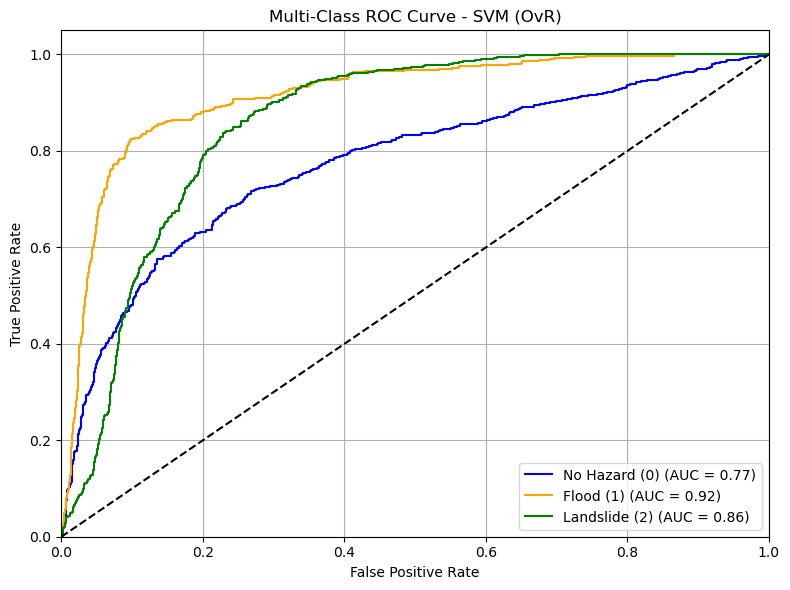

In [4]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize y_test for ROC
y_test_bin = label_binarize(y_test, classes=classes)
y_score = svm.best_estimator_.predict_proba(X_test_selected)
n_classes = len(classes)

# Compute ROC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard (0)', 'Flood (1)', 'Landslide (2)']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve - SVM (OvR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

# Predict class labels and probabilities
y_pred_svm = svm.predict(X_test_selected)
probs = svm.predict_proba(X_test_selected)  # shape: [n_samples, n_classes]

# Build DataFrame with probabilities for each class
df_svm = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred_svm,
    'Prob_Class_0': probs[:, 0],
    'Prob_Class_1': probs[:, 1],
    'Prob_Class_2': probs[:, 2]
})

# Save to CSV
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SVM_Combined_Results.csv"
df_svm.to_csv(save_path, index=False)

print(f"Saved multi-class SVM predictions to {save_path}")


Saved multi-class SVM predictions to C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\SVM_Combined_Results.csv
